In [26]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

from tensorflow.keras.datasets import fashion_mnist

# Load dataset
(X_train, y_train), (X_test, y_test) = fashion_mnist.load_data()

print("Training Images Shape :", X_train.shape)
print("Training Labels Shape :", y_train.shape)
print("Testing Images Shape  :", X_test.shape)
print("Testing Labels Shape  :", y_test.shape)

class_names = [
    'T-shirt/Top','Trouser','Pullover','Dress',
    'Coat','Sandal','Shirt','Sneaker',
    'Bag','Ankle Boot'
]

Training Images Shape : (60000, 28, 28)
Training Labels Shape : (60000,)
Testing Images Shape  : (10000, 28, 28)
Testing Labels Shape  : (10000,)


In [2]:
import os

# Create folder to save plots
os.makedirs("plots", exist_ok=True)

def save_plot(filename):
    plt.savefig(
        f"plots/{filename}.png",
        dpi=300,
        bbox_inches="tight"
    )

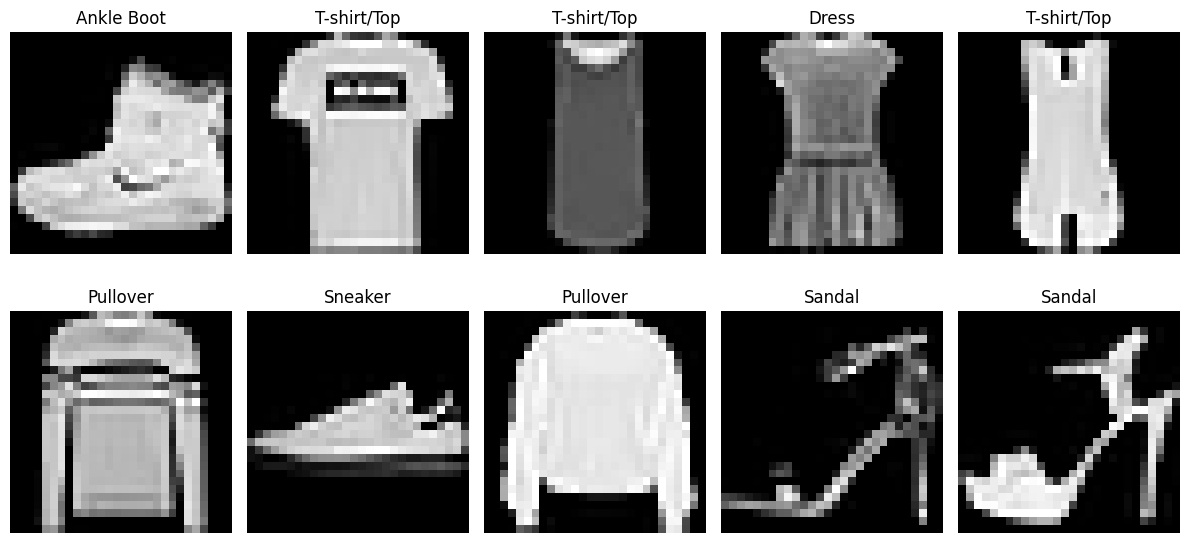

In [3]:
plt.figure(figsize=(12,6))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i], cmap='gray')
    plt.title(class_names[y_train[i]])
    plt.axis('off')

plt.tight_layout()
save_plot("sample_images")
plt.show()

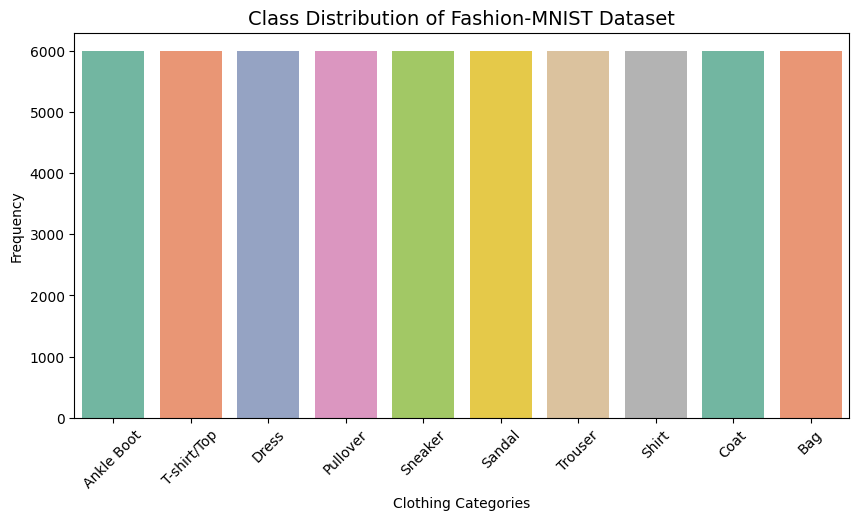

In [4]:
plt.figure(figsize=(10,5))

sns.countplot(
    x=[class_names[i] for i in y_train],
    hue=[class_names[i] for i in y_train],  # fixes seaborn warning
    palette="Set2",
    legend=False
)

plt.title("Class Distribution of Fashion-MNIST Dataset", fontsize=14)
plt.xlabel("Clothing Categories")
plt.ylabel("Frequency")
plt.xticks(rotation=45)
save_plot("class_distribution")
plt.show()

In [5]:
#flatten images

X_train_flat = X_train.reshape(60000, 784)
X_test_flat = X_test.reshape(10000, 784)

print("Before Flattening:", X_train.shape)
print("After Flattening :", X_train_flat.shape)

Before Flattening: (60000, 28, 28)
After Flattening : (60000, 784)


In [6]:
X_train_flat = X_train_flat / 255.0
X_test_flat = X_test_flat / 255.0

In [7]:
from tensorflow.keras.utils import to_categorical

y_train_cat = to_categorical(y_train, 10)
y_test_cat = to_categorical(y_test, 10)

print("Encoded Label Shape:", y_train_cat.shape)

Encoded Label Shape: (60000, 10)


In [8]:
from tensorflow import keras
from tensorflow.keras import layers

model = keras.Sequential([
    layers.Input(shape=(784,)),
    layers.Dense(128, activation='relu'),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 128)            │       100,480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 109,386 (427.29 KB)

 Trainable params: 109,386 (427.29 KB)

 Non-trainable params: 0 (0.00 B)

In [9]:
model.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    X_train_flat,
    y_train_cat,
    epochs=20,
    batch_size=32,
    validation_split=0.2
)

Epoch 1/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.8164 - loss: 0.5205 - val_accuracy: 0.8528 - val_loss: 0.4168
Epoch 2/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8609 - loss: 0.3822 - val_accuracy: 0.8524 - val_loss: 0.3985
Epoch 3/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8745 - loss: 0.3429 - val_accuracy: 0.8721 - val_loss: 0.3448
Epoch 4/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.8824 - loss: 0.3180 - val_accuracy: 0.8767 - val_loss: 0.3505
Epoch 5/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8880 - loss: 0.3001 - val_accuracy: 0.8744 - val_loss: 0.3481
Epoch 6/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 8s 6ms/step - accuracy: 0.8931 - loss: 0.2865 - val_accuracy: 0.8787 - val_loss: 0.3395
Epoch 7/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.8978 - loss: 0.2710 - val_accuracy: 0.8831 - val_loss: 0.3291
Epoch 8/20
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 9s 6ms/step - accuracy: 0.9031 - loss: 0.2595 -

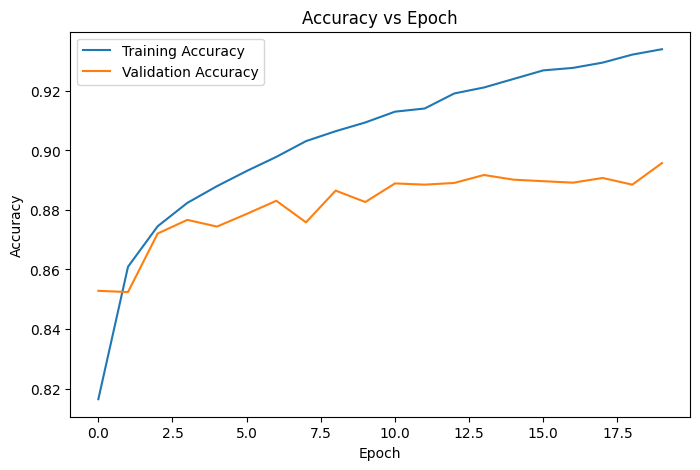

In [10]:
plt.figure(figsize=(8,5))

plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')

plt.title("Accuracy vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()
save_plot("baseline_accuracy")
plt.show()

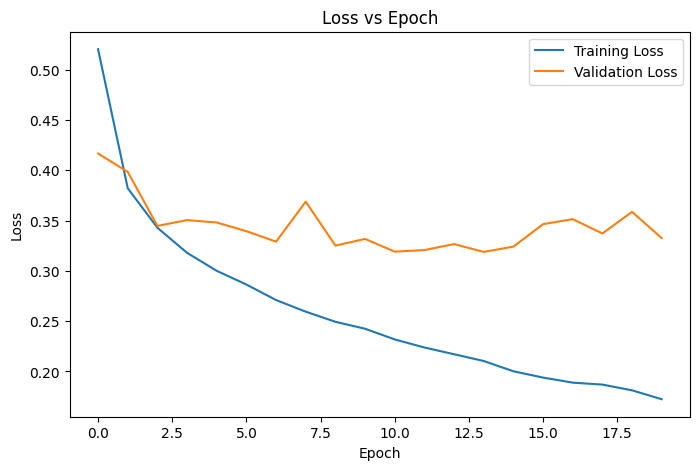

In [11]:
plt.figure(figsize=(8,5))

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')

plt.title("Loss vs Epoch")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
save_plot("baseline_loss")
plt.show()

In [12]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

baseline_pred_prob = model.predict(X_test_flat)
baseline_pred = np.argmax(baseline_pred_prob, axis=1)

baseline_accuracy = accuracy_score(y_test, baseline_pred)
baseline_precision = precision_score(y_test, baseline_pred, average='weighted')
baseline_recall = recall_score(y_test, baseline_pred, average='weighted')
baseline_f1 = f1_score(y_test, baseline_pred, average='weighted')

print("Accuracy :", baseline_accuracy)
print("Precision:", baseline_precision)
print("Recall   :", baseline_recall)
print("F1 Score :", baseline_f1)
print(classification_report(y_test, baseline_pred))

313/313 ━━━━━━━━━━━━━━━━━━━━ 2s 6ms/step
Accuracy : 0.8922
Precision: 0.8918132674723145
Recall   : 0.8922
F1 Score : 0.8919133120837681
              precision    recall  f1-score   support

           0       0.83      0.85      0.84      1000
           1       0.99      0.97      0.98      1000
           2       0.81      0.80      0.81      1000
           3       0.89      0.91      0.90      1000
           4       0.82      0.82      0.82      1000
           5       0.98      0.97      0.97      1000
           6       0.73      0.71      0.72      1000
           7       0.94      0.97      0.96      1000
           8       0.96      0.97      0.97      1000
           9       0.97      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



In [13]:
loss, acc = model.evaluate(X_test_flat, y_test_cat, verbose=0)
print(acc)

0.8921999931335449


              precision    recall  f1-score   support

           0       0.83      0.85      0.84      1000
           1       0.99      0.97      0.98      1000
           2       0.81      0.80      0.81      1000
           3       0.89      0.91      0.90      1000
           4       0.82      0.82      0.82      1000
           5       0.98      0.97      0.97      1000
           6       0.73      0.71      0.72      1000
           7       0.94      0.97      0.96      1000
           8       0.96      0.97      0.97      1000
           9       0.97      0.95      0.96      1000

    accuracy                           0.89     10000
   macro avg       0.89      0.89      0.89     10000
weighted avg       0.89      0.89      0.89     10000



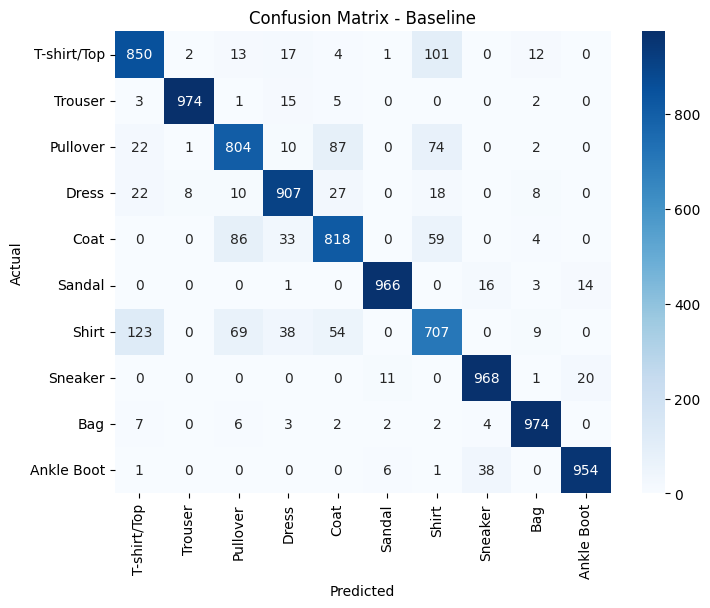

In [14]:
print(classification_report(y_test, baseline_pred))

cm = confusion_matrix(y_test, baseline_pred)

plt.figure(figsize=(8,6))
sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Baseline")
plt.xlabel("Predicted")
plt.ylabel("Actual")
save_plot("baseline_confusion_matrix")
plt.show()

In [15]:
from tensorflow import keras
from tensorflow.keras import layers

def create_model(hidden_layers=2,
                 neurons=128,
                 activation='relu',
                 dropout=0.0,
                 optimizer='adam',
                 lr=0.001):

    model = keras.Sequential()
    model.add(layers.Input(shape=(784,)))

    for _ in range(hidden_layers):
        model.add(layers.Dense(neurons, activation=activation))
        if dropout > 0:
            model.add(layers.Dropout(dropout))

    model.add(layers.Dense(10, activation='softmax'))

    if optimizer == 'adam':
        opt = keras.optimizers.Adam(learning_rate=lr)
    elif optimizer == 'sgd':
        opt = keras.optimizers.SGD(learning_rate=lr)
    else:
        opt = keras.optimizers.RMSprop(learning_rate=lr)

    model.compile(
        optimizer=opt,
        loss='categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

In [37]:
!pip install scikeras

In [38]:
!pip uninstall -y scikeras scikit-learn
!pip install scikit-learn==1.5.2
!pip install scikeras==0.13.0

Found existing installation: scikeras 0.13.0
Uninstalling scikeras-0.13.0:
  Successfully uninstalled scikeras-0.13.0
Found existing installation: scikit-learn 1.5.2
Uninstalling scikit-learn-1.5.2:
  Successfully uninstalled scikit-learn-1.5.2
  Using cached scikit_learn-1.5.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (13 kB)
Using cached scikit_learn-1.5.2-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (12.9 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
hdbscan 0.8.44 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.
umap-learn 0.5.12 requires scikit-learn>=1.6, but you have scikit-learn 1.5.2 which is incompatible.


  Using cached scikeras-0.13.0-py3-none-any.whl.metadata (3.1 kB)
Using cached scikeras-0.13.0-py3-none-any.whl (26 kB)


In [16]:
from scikeras.wrappers import KerasClassifier

clf = KerasClassifier(
    model=create_model,
    verbose=0
)

In [17]:
param_dist = {

    "model__hidden_layers":[1,2,3],

    "model__neurons":[32,64,128,256],

    "model__activation":[
        "relu",
        "tanh",
        "sigmoid"
    ],

    "model__dropout":[
        0.0,
        0.2,
        0.5
    ],

    "model__optimizer":[
        "adam",
        "sgd",
        "rmsprop"
    ],

    "model__lr":[
        0.1,
        0.01,
        0.001
    ],

    "batch_size":[
        16,
        32,
        64,
        128
    ],

    "epochs":[
        10,
        20,
        30
    ]

}

In [18]:
from sklearn.model_selection import RandomizedSearchCV

search = RandomizedSearchCV(

    estimator=clf,

    param_distributions=param_dist,

    n_iter=8,

    cv=5,

    verbose=2,

    random_state=42,

    n_jobs=1

)
search.fit(
    X_train_flat[:10000],
    y_train_cat[:10000]
)

Fitting 5 folds for each of 8 candidates, totalling 40 fits
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__hidden_layers=1, model__lr=0.001, model__neurons=256, model__optimizer=sgd; total time=  13.4s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__hidden_layers=1, model__lr=0.001, model__neurons=256, model__optimizer=sgd; total time=  13.5s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__hidden_layers=1, model__lr=0.001, model__neurons=256, model__optimizer=sgd; total time=  14.0s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__hidden_layers=1, model__lr=0.001, model__neurons=256, model__optimizer=sgd; total time=  13.9s
[CV] END batch_size=64, epochs=20, model__activation=tanh, model__dropout=0.2, model__hidden_layers=1, model__lr=0.001, model__neurons=256, model__optimizer=sgd; total time=  13.4s
[CV] END batch_size=16, epochs=10, 

RandomizedSearchCV(cv=5,
                   estimator=KerasClassifier(model=<function create_model at 0x7fa182202de0>, verbose=0),
                   n_iter=8, n_jobs=1,
                   param_distributions={'batch_size': [16, 32, 64, 128],
                                        'epochs': [10, 20, 30],
                                        'model__activation': ['relu', 'tanh',
                                                              'sigmoid'],
                                        'model__dropout': [0.0, 0.2, 0.5],
                                        'model__hidden_layers': [1, 2, 3],
                                        'model__lr': [0.1, 0.01, 0.001],
                                        'model__neurons': [32, 64, 128, 256],
                                        'model__optimizer': ['adam', 'sgd',
                                                             'rmsprop']},
                   random_state=42, verbose=2)

In [19]:
best_params = search.best_params_

print("Best Hyperparameters:")
for key, value in best_params.items():
    print(f"{key}: {value}")


print("Best Cross-validation Accuracy:")
print(search.best_score_)

Best Hyperparameters:
model__optimizer: sgd
model__neurons: 128
model__lr: 0.1
model__hidden_layers: 1
model__dropout: 0.0
model__activation: tanh
epochs: 30
batch_size: 32
Best Cross-validation Accuracy:
0.8513


In [20]:
best_model = create_model(
    hidden_layers=best_params['model__hidden_layers'],
    neurons=best_params['model__neurons'],
    activation=best_params['model__activation'],
    dropout=best_params['model__dropout'],
    optimizer=best_params['model__optimizer'],
    lr=best_params['model__lr']
)

history_opt = best_model.fit(
    X_train_flat,
    y_train_cat,
    epochs=best_params['epochs'],
    batch_size=best_params['batch_size'],
    validation_split=0.2,
    verbose=1
)

Epoch 1/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 12s 8ms/step - accuracy: 0.8079 - loss: 0.5413 - val_accuracy: 0.8476 - val_loss: 0.4226
Epoch 2/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8470 - loss: 0.4209 - val_accuracy: 0.8434 - val_loss: 0.4273
Epoch 3/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 10s 3ms/step - accuracy: 0.8597 - loss: 0.3856 - val_accuracy: 0.8561 - val_loss: 0.3871
Epoch 4/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8668 - loss: 0.3627 - val_accuracy: 0.8702 - val_loss: 0.3529
Epoch 5/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8731 - loss: 0.3440 - val_accuracy: 0.8719 - val_loss: 0.3570
Epoch 6/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8780 - loss: 0.3303 - val_accuracy: 0.8611 - val_loss: 0.3833
Epoch 7/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.8816 - loss: 0.3163 - val_accuracy: 0.8656 - val_loss: 0.3682
Epoch 8/30
1500/1500 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8879 - loss: 0.3053 

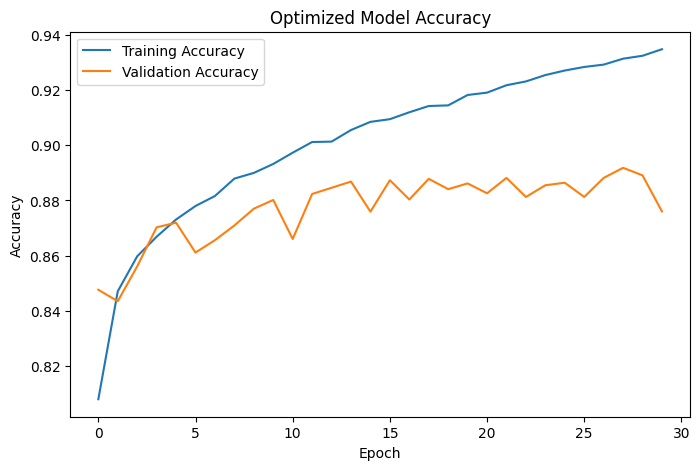

In [21]:
plt.figure(figsize=(8,5))

plt.plot(history_opt.history['accuracy'], label='Training Accuracy')
plt.plot(history_opt.history['val_accuracy'], label='Validation Accuracy')

plt.title("Optimized Model Accuracy")
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.legend()


save_plot("optimized_accuracy")
plt.show()

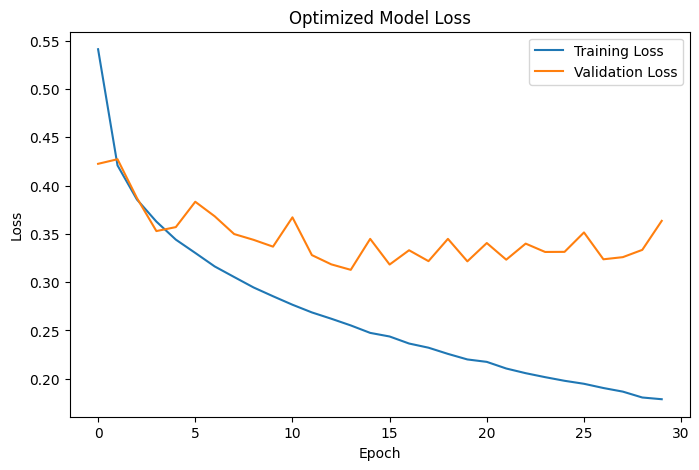

In [22]:
plt.figure(figsize=(8,5))

plt.plot(history_opt.history['loss'], label='Training Loss')
plt.plot(history_opt.history['val_loss'], label='Validation Loss')

plt.title("Optimized Model Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.legend()
save_plot("optimized_loss")
plt.show()

In [23]:
from sklearn.metrics import accuracy_score
from sklearn.metrics import precision_score
from sklearn.metrics import recall_score
from sklearn.metrics import f1_score

opt_pred_prob = best_model.predict(X_test_flat)
opt_pred = np.argmax(opt_pred_prob, axis=1)

opt_accuracy = accuracy_score(y_test, opt_pred)
opt_precision = precision_score(y_test, opt_pred, average='weighted')
opt_recall = recall_score(y_test, opt_pred, average='weighted')
opt_f1 = f1_score(y_test, opt_pred, average='weighted')
print("Optimized Accuracy :", opt_accuracy)
print("Optimized Precision:", opt_precision)
print("Optimized Recall   :", opt_recall)
print("Optimized F1 Score :", opt_f1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step
Optimized Accuracy : 0.8686
Optimized Precision: 0.8751123673268301
Optimized Recall   : 0.8686
Optimized F1 Score : 0.8680126232932589


              precision    recall  f1-score   support

           0       0.80      0.86      0.83      1000
           1       0.99      0.97      0.98      1000
           2       0.90      0.60      0.72      1000
           3       0.87      0.90      0.89      1000
           4       0.76      0.83      0.79      1000
           5       0.97      0.93      0.95      1000
           6       0.63      0.73      0.68      1000
           7       0.94      0.94      0.94      1000
           8       0.97      0.96      0.96      1000
           9       0.92      0.97      0.95      1000

    accuracy                           0.87     10000
   macro avg       0.88      0.87      0.87     10000
weighted avg       0.88      0.87      0.87     10000



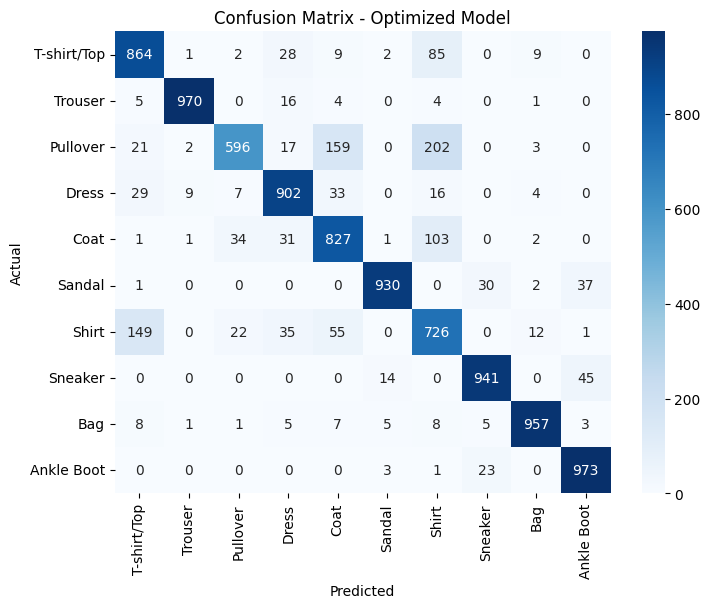

In [24]:
from sklearn.metrics import confusion_matrix, classification_report

print(classification_report(y_test, opt_pred))

cm = confusion_matrix(y_test, opt_pred)

plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues',
    xticklabels=class_names,
    yticklabels=class_names
)

plt.title("Confusion Matrix - Optimized Model")
plt.xlabel("Predicted")
plt.ylabel("Actual")
save_plot("optimized_confusion_matrix")
plt.show()

In [27]:
comparison = pd.DataFrame({

    "Metric":[
        "Accuracy",
        "Precision",
        "Recall",
        "F1 Score"
    ],

    "Baseline":[
        baseline_accuracy,
        baseline_precision,
        baseline_recall,
        baseline_f1
    ],

    "Optimized":[
        opt_accuracy,
        opt_precision,
        opt_recall,
        opt_f1
    ]

})

comparison

,Metric,Baseline,Optimized
0,Accuracy,0.892200,0.868600
1,Precision,0.891813,0.875112
2,Recall,0.892200,0.868600
3,F1 Score,0.891913,0.868013


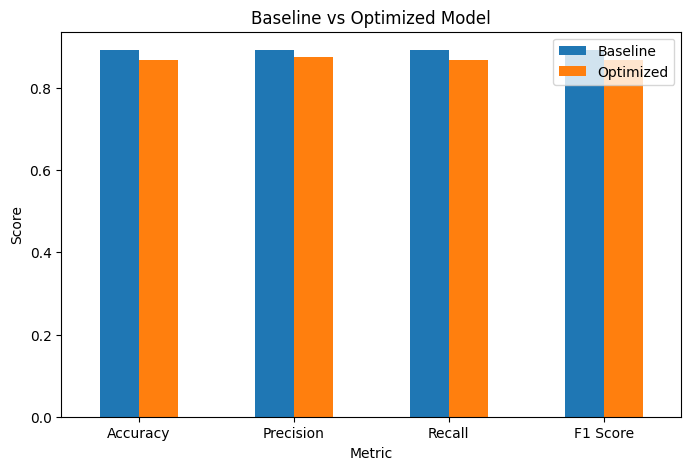

In [29]:
comparison.set_index("Metric").plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Baseline vs Optimized Model")
plt.ylabel("Score")
plt.xticks(rotation=0)
save_plot("baseline_vs_optimized")
plt.show()